In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [4]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate Rows: 0


In [5]:
print("Churn Distribution:")
print(df["Churn"].value_counts())

print("\nChurn Percentage:")
print(df["Churn"].value_counts(normalize=True) * 100)

Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [6]:
print("TotalCharges Data Type:", df["TotalCharges"].dtype)

print(
    "Blank TotalCharges Values:",
    (df["TotalCharges"].astype(str).str.strip() == "").sum()
)

TotalCharges Data Type: str
Blank TotalCharges Values: 11


In [10]:
df.shape

(7043, 21)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## Data Cleaning

The dataset was inspected for missing values, duplicate records, incorrect data types, and irrelevant identifier columns.

The `TotalCharges` column was stored as a string because it contained blank values. These blank values were converted to missing values and removed from the dataset because they represented only a very small proportion of the total observations.

The `customerID` column was removed because it is a unique identifier and does not provide meaningful predictive information for customer churn prediction.

In [12]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print("Missing Values After Conversion:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing Values After Conversion:
TotalCharges    11
dtype: int64


In [13]:
df = df.dropna(subset=["TotalCharges"]).copy()

print("Dataset Shape After Cleaning:", df.shape)
print("Missing Values:", df.isnull().sum().sum())

Dataset Shape After Cleaning: (7032, 21)
Missing Values: 0


In [14]:
df = df.drop("customerID", axis=1)

print("Final Dataset Shape:", df.shape)

Final Dataset Shape: (7032, 20)


## Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand customer churn patterns, examine the distribution of numerical features, and analyze how customer characteristics and service-related variables are associated with churn.

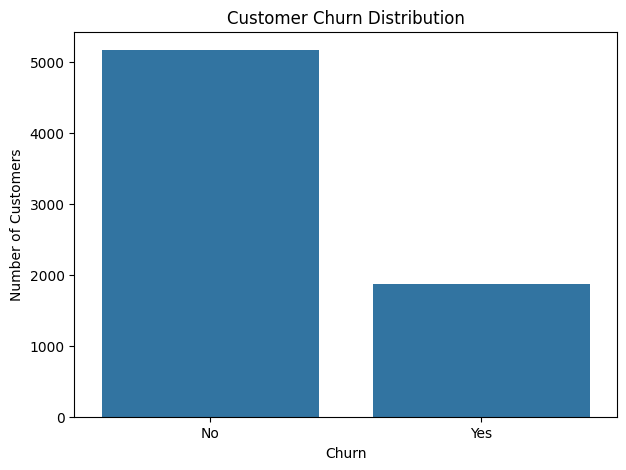

In [15]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [16]:
churn_percentage = (
    df["Churn"]
    .value_counts(normalize=True)
    .mul(100)
)

print(churn_percentage)

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


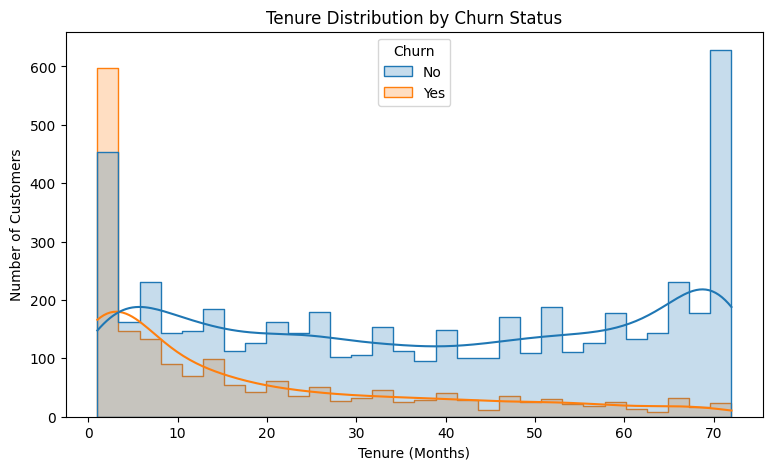

In [17]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True,
    element="step"
)

plt.title("Tenure Distribution by Churn Status")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

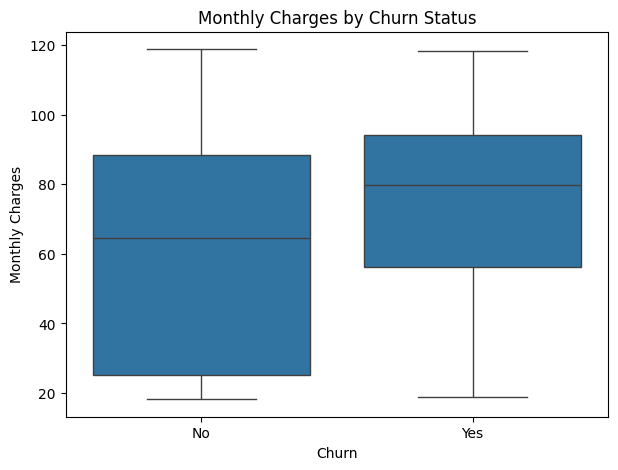

In [18]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [19]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


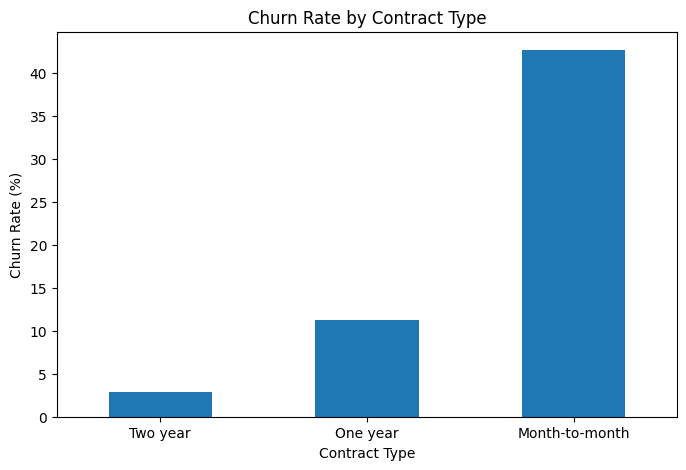

In [20]:
contract_churn["Yes"].sort_values().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [21]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


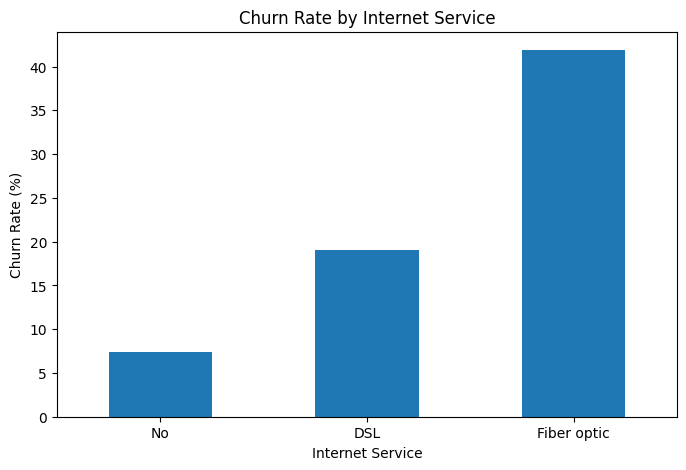

In [22]:
internet_churn["Yes"].sort_values().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

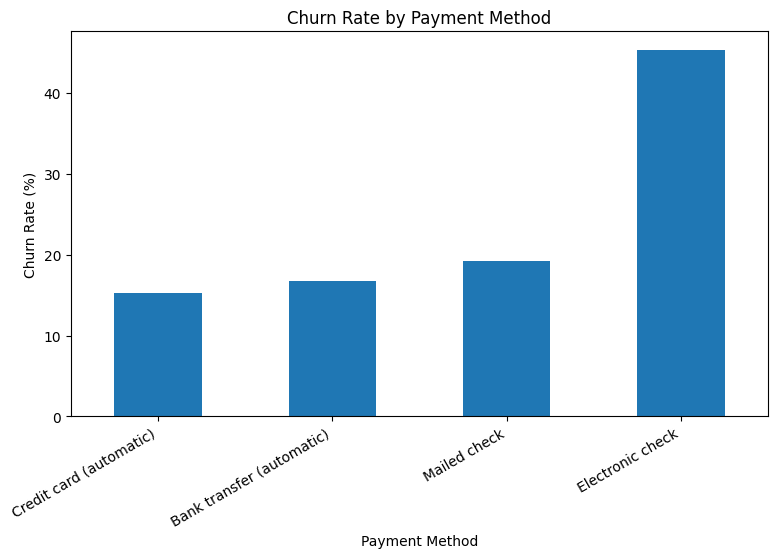

In [23]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

payment_churn["Yes"].sort_values().plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30, ha="right")

plt.show()


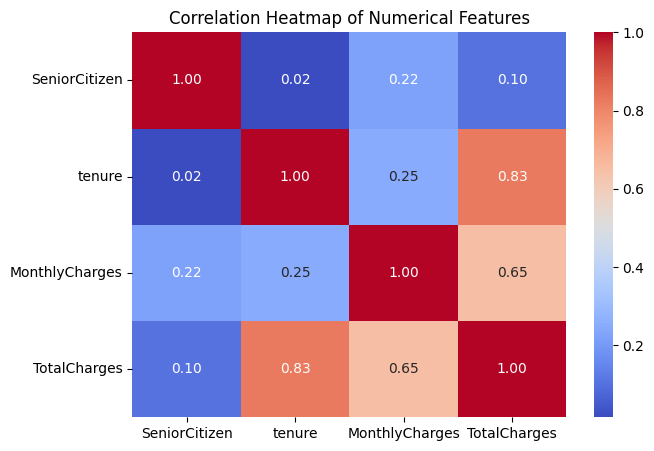

In [24]:
numerical_columns = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

plt.figure(figsize=(7, 5))

sns.heatmap(
    df[numerical_columns].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap of Numerical Features")

plt.show()

## EDA Observations

- The target variable is moderately imbalanced, with approximately 73.5% of customers belonging to the non-churn class and 26.5% belonging to the churn class.

- Payment method shows a clear association with customer churn. Customers using electronic check have the highest churn rate, while customers using automatic payment methods have substantially lower churn rates.

- Internet service type is also associated with churn. Fiber optic customers have the highest churn rate, followed by DSL customers, while customers without internet service have the lowest churn rate.

- The numerical feature correlation heatmap shows a strong positive correlation of 0.83 between tenure and TotalCharges. This is expected because customers with longer tenure generally accumulate higher total charges.

- MonthlyCharges and TotalCharges have a positive correlation of 0.65, indicating that customers with higher monthly charges tend to accumulate higher total charges.

- The correlation heatmap includes only numerical features and does not directly measure their relationship with the categorical target variable, Churn.

Overall, the exploratory analysis indicates that customer contract characteristics, payment methods, internet services, tenure, and charges may provide useful information for predicting customer churn.

In [25]:
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [26]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (7032, 19)
Target Shape: (7032,)


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("\nTraining Churn Distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting Churn Distribution:")
print(y_test.value_counts(normalize=True))

Training Features: (5625, 19)
Testing Features: (1407, 19)

Training Churn Distribution:
Churn
0    0.734222
1    0.265778
Name: proportion, dtype: float64

Testing Churn Distribution:
Churn
0    0.734186
1    0.265814
Name: proportion, dtype: float64


In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numerical_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_features = X.select_dtypes(
    include="object"
).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)


Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [29]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

## Model 1: Logistic Regression

Logistic Regression is used as the baseline classification model for predicting customer churn. Numerical features are standardized, while categorical variables are transformed using one-hot encoding.

The preprocessing steps and classification algorithm are combined into a machine learning pipeline to prevent data leakage and ensure that the same transformations can be applied consistently to training data, testing data, and future customer records.

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessor", preprocessor),

    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [31]:
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [33]:
y_pred_lr = logistic_model.predict(X_test)

y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

In [34]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression Performance")
print("--------------------------------")
print(f"Accuracy  : {accuracy_lr:.4f}")
print(f"Precision : {precision_lr:.4f}")
print(f"Recall    : {recall_lr:.4f}")
print(f"F1 Score  : {f1_lr:.4f}")
print(f"ROC-AUC   : {roc_auc_lr:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Performance
--------------------------------
Accuracy  : 0.8053
Precision : 0.6515
Recall    : 0.5749
F1 Score  : 0.6108
ROC-AUC   : 0.8361

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.81      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.81      0.80      1407



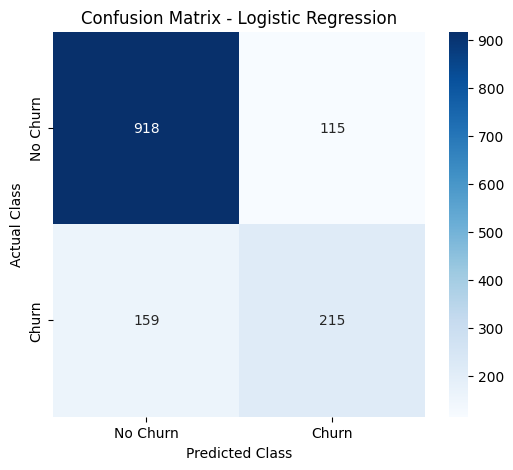

In [35]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

### Logistic Regression Results

The Logistic Regression model achieved an accuracy of approximately 80.5% and a ROC-AUC score of 0.836, indicating good overall classification and ranking performance.

For the churn class, the model achieved a precision of 65.2%, recall of 57.5%, and an F1-score of 61.1%.

The confusion matrix shows that the model correctly identified 215 customers who churned and 918 customers who did not churn. However, 159 churned customers were incorrectly classified as non-churners.

Since identifying customers who are likely to leave is an important objective of churn prediction, recall and F1-score for the churn class are important evaluation metrics in addition to accuracy and ROC-AUC.

Overall, Logistic Regression provides a strong baseline model, although there is potential to improve the detection of churned customers.

In [37]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = Pipeline([
    ("preprocessor", preprocessor),

    ("classifier", DecisionTreeClassifier(
        random_state=42
    ))
])

decision_tree_model.fit(X_train, y_train)

y_pred_dt = decision_tree_model.predict(X_test)
y_prob_dt = decision_tree_model.predict_proba(X_test)[:, 1]

In [38]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, y_prob_dt)

print("Decision Tree Performance")
print("--------------------------------")
print(f"Accuracy  : {accuracy_dt:.4f}")
print(f"Precision : {precision_dt:.4f}")
print(f"Recall    : {recall_dt:.4f}")
print(f"F1 Score  : {f1_dt:.4f}")
print(f"ROC-AUC   : {roc_auc_dt:.4f}")

Decision Tree Performance
--------------------------------
Accuracy  : 0.7164
Precision : 0.4661
Recall    : 0.4599
F1 Score  : 0.4630
ROC-AUC   : 0.6343


In [39]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline([
    ("preprocessor", preprocessor),

    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

random_forest_model.fit(X_train, y_train)

y_pred_rf = random_forest_model.predict(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

In [40]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Performance")
print("--------------------------------")
print(f"Accuracy  : {accuracy_rf:.4f}")
print(f"Precision : {precision_rf:.4f}")
print(f"Recall    : {recall_rf:.4f}")
print(f"F1 Score  : {f1_rf:.4f}")
print(f"ROC-AUC   : {roc_auc_rf:.4f}")

Random Forest Performance
--------------------------------
Accuracy  : 0.7882
Precision : 0.6234
Recall    : 0.5134
F1 Score  : 0.5630
ROC-AUC   : 0.8156


In [41]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        accuracy_lr,
        accuracy_dt,
        accuracy_rf
    ],

    "Precision": [
        precision_lr,
        precision_dt,
        precision_rf
    ],

    "Recall": [
        recall_lr,
        recall_dt,
        recall_rf
    ],

    "F1 Score": [
        f1_lr,
        f1_dt,
        f1_rf
    ],

    "ROC-AUC": [
        roc_auc_lr,
        roc_auc_dt,
        roc_auc_rf
    ]
})

model_results.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.805259,0.651515,0.574866,0.610795,0.836074
1,Random Forest,0.788202,0.623377,0.513369,0.563050,0.815628
2,Decision Tree,0.716418,0.466125,0.459893,0.462988,0.634332


### Model Comparison

Three classification algorithms were evaluated for customer churn prediction: Logistic Regression, Decision Tree Classifier, and Random Forest Classifier.

Logistic Regression achieved the best overall performance with an accuracy of approximately 80.5%, an F1-score of 0.611, and a ROC-AUC score of 0.836. It also achieved the highest recall among the evaluated models, correctly identifying a larger proportion of customers who churned.

Random Forest achieved an accuracy of approximately 78.8% and a ROC-AUC score of 0.816. Although its overall performance was relatively strong, its recall and F1-score were lower than those of Logistic Regression.

Decision Tree achieved the weakest performance with an accuracy of approximately 71.6% and a ROC-AUC score of 0.634, indicating weaker generalization to unseen customer data.

Based on the current test-set results, Logistic Regression provides the best overall predictive performance.

In [42]:
from sklearn.metrics import roc_auc_score

models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model
}

for name, model in models.items():

    train_prob = model.predict_proba(X_train)[:, 1]
    test_prob = model.predict_proba(X_test)[:, 1]

    train_auc = roc_auc_score(y_train, train_prob)
    test_auc = roc_auc_score(y_test, test_prob)

    print(name)
    print(f"Training ROC-AUC : {train_auc:.4f}")
    print(f"Testing ROC-AUC  : {test_auc:.4f}")
    print("-" * 35)

Logistic Regression
Training ROC-AUC : 0.8506
Testing ROC-AUC  : 0.8361
-----------------------------------
Decision Tree
Training ROC-AUC : 1.0000
Testing ROC-AUC  : 0.6343
-----------------------------------
Random Forest
Training ROC-AUC : 1.0000
Testing ROC-AUC  : 0.8156
-----------------------------------


In [43]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for name, model in models.items():

    cv_scores = cross_val_score(
        model,
        X,
        y,
        cv=skf,
        scoring="roc_auc",
        n_jobs=-1
    )

    print(name)
    print("Cross-Validation ROC-AUC Scores:", np.round(cv_scores, 4))
    print(f"Mean CV ROC-AUC : {cv_scores.mean():.4f}")
    print(f"Std CV ROC-AUC  : {cv_scores.std():.4f}")
    print("-" * 55)

Logistic Regression
Cross-Validation ROC-AUC Scores: [0.8474 0.8477 0.8453 0.8446 0.8402]
Mean CV ROC-AUC : 0.8451
Std CV ROC-AUC  : 0.0027
-------------------------------------------------------
Decision Tree
Cross-Validation ROC-AUC Scores: [0.66   0.6494 0.6525 0.6758 0.6538]
Mean CV ROC-AUC : 0.6583
Std CV ROC-AUC  : 0.0094
-------------------------------------------------------
Random Forest
Cross-Validation ROC-AUC Scores: [0.8265 0.8265 0.822  0.8229 0.8144]
Mean CV ROC-AUC : 0.8225
Std CV ROC-AUC  : 0.0044
-------------------------------------------------------


### Overfitting and Cross-Validation Analysis

The training and testing ROC-AUC scores were compared to evaluate the generalization performance of the classification models.

Logistic Regression achieved a training ROC-AUC score of 0.851 and a testing ROC-AUC score of 0.836. The small difference between the training and testing scores indicates that the model generalizes well to unseen customer data.

Decision Tree achieved a perfect training ROC-AUC score of 1.000 but a testing ROC-AUC score of only 0.634. This large performance gap indicates severe overfitting.

Random Forest also achieved a training ROC-AUC score of 1.000, while its testing ROC-AUC score decreased to 0.816, indicating overfitting.

Five-fold stratified cross-validation further confirmed the stability of Logistic Regression. It achieved the highest mean cross-validation ROC-AUC score of 0.845 with a very low standard deviation of 0.003.

Based on test-set performance, training-testing score comparison, and cross-validation results, Logistic Regression provides the best overall generalization performance among the evaluated models.

## Improving Churn Detection with Class Weighting

The dataset contains fewer churned customers than non-churned customers. To increase the model's sensitivity toward the minority churn class, Logistic Regression is trained using balanced class weights.

The balanced class weighting strategy automatically assigns higher importance to observations from the minority class. The resulting model is compared with the baseline Logistic Regression model using precision, recall, F1-score, and ROC-AUC.

In [45]:
balanced_logistic_model = Pipeline([
    ("preprocessor", preprocessor),

    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

balanced_logistic_model.fit(X_train, y_train)

y_pred_balanced = balanced_logistic_model.predict(X_test)
y_prob_balanced = balanced_logistic_model.predict_proba(X_test)[:, 1]

In [46]:
accuracy_balanced = accuracy_score(y_test, y_pred_balanced)
precision_balanced = precision_score(y_test, y_pred_balanced)
recall_balanced = recall_score(y_test, y_pred_balanced)
f1_balanced = f1_score(y_test, y_pred_balanced)
roc_auc_balanced = roc_auc_score(y_test, y_prob_balanced)

print("Balanced Logistic Regression Performance")
print("-----------------------------------------")
print(f"Accuracy  : {accuracy_balanced:.4f}")
print(f"Precision : {precision_balanced:.4f}")
print(f"Recall    : {recall_balanced:.4f}")
print(f"F1 Score  : {f1_balanced:.4f}")
print(f"ROC-AUC   : {roc_auc_balanced:.4f}")

Balanced Logistic Regression Performance
-----------------------------------------
Accuracy  : 0.7264
Precision : 0.4909
Recall    : 0.7941
F1 Score  : 0.6067
ROC-AUC   : 0.8353


In [47]:
logistic_comparison = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "Balanced Logistic Regression"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_balanced
    ],
    "Precision": [
        precision_lr,
        precision_balanced
    ],
    "Recall": [
        recall_lr,
        recall_balanced
    ],
    "F1 Score": [
        f1_lr,
        f1_balanced
    ],
    "ROC-AUC": [
        roc_auc_lr,
        roc_auc_balanced
    ]
})

logistic_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Baseline Logistic Regression,0.805259,0.651515,0.574866,0.610795,0.836074
1,Balanced Logistic Regression,0.726368,0.490909,0.794118,0.606742,0.835313


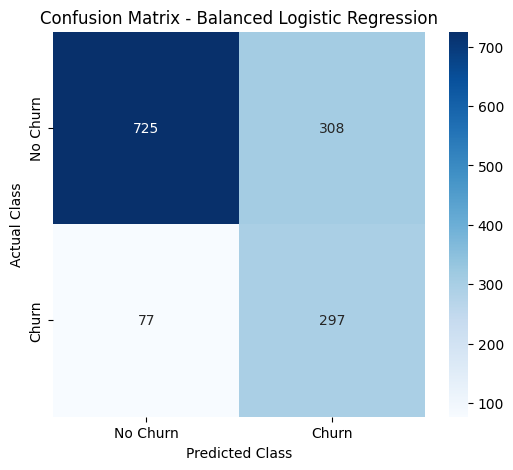

In [48]:
cm_balanced = confusion_matrix(y_test, y_pred_balanced)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_balanced,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Confusion Matrix - Balanced Logistic Regression")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

### Effect of Class Weighting

Balanced class weighting substantially increased the model's ability to identify customers who churned.

The recall for the churn class increased from approximately 57.5% with the baseline Logistic Regression model to 79.4% with the Balanced Logistic Regression model.

The number of correctly identified churned customers increased from 215 to 297, while the number of missed churned customers decreased from 159 to 77.

However, the improvement in recall resulted in lower precision and accuracy. The number of non-churned customers incorrectly classified as churned increased from 115 to 308.

The ROC-AUC scores of the two models were nearly identical, indicating that class weighting primarily changed the classification trade-off rather than substantially improving the model's overall ranking ability.

For a churn prevention system where identifying as many at-risk customers as possible is the primary objective, the Balanced Logistic Regression model may be preferred because of its substantially higher recall.

In [49]:
from sklearn.metrics import precision_recall_curve

precision_values, recall_values, thresholds = precision_recall_curve(
    y_test,
    y_prob_lr
)

threshold_results = pd.DataFrame({
    "Threshold": thresholds,
    "Precision": precision_values[:-1],
    "Recall": recall_values[:-1]
})

threshold_results.head()

,Threshold,Precision,Recall
0,0.001465,0.265814,1.0
1,0.001483,0.266003,1.0
2,0.001493,0.266192,1.0
3,0.001567,0.266382,1.0
4,0.001655,0.266572,1.0


In [50]:
threshold_results["F1 Score"] = (
    2
    * threshold_results["Precision"]
    * threshold_results["Recall"]
    / (
        threshold_results["Precision"]
        + threshold_results["Recall"]
    )
)

best_threshold_row = threshold_results.loc[
    threshold_results["F1 Score"].idxmax()
]

best_threshold_row

Threshold    0.405353
Precision    0.580866
Recall       0.681818
F1 Score     0.627306
Name: 967, dtype: float64

In [51]:
best_threshold = best_threshold_row["Threshold"]

y_pred_tuned = (
    y_prob_lr >= best_threshold
).astype(int)

accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)

print("Best Threshold:", round(best_threshold, 4))

print("\nTuned Logistic Regression Performance")
print("-------------------------------------")
print(f"Accuracy  : {accuracy_tuned:.4f}")
print(f"Precision : {precision_tuned:.4f}")
print(f"Recall    : {recall_tuned:.4f}")
print(f"F1 Score  : {f1_tuned:.4f}")
print(f"ROC-AUC   : {roc_auc_lr:.4f}")

Best Threshold: 0.4054

Tuned Logistic Regression Performance
-------------------------------------
Accuracy  : 0.7846
Precision : 0.5809
Recall    : 0.6818
F1 Score  : 0.6273
ROC-AUC   : 0.8361


In [52]:
final_logistic_comparison = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "Balanced Logistic Regression",
        "Threshold-Tuned Logistic Regression"
    ],

    "Accuracy": [
        accuracy_lr,
        accuracy_balanced,
        accuracy_tuned
    ],

    "Precision": [
        precision_lr,
        precision_balanced,
        precision_tuned
    ],

    "Recall": [
        recall_lr,
        recall_balanced,
        recall_tuned
    ],

    "F1 Score": [
        f1_lr,
        f1_balanced,
        f1_tuned
    ],

    "ROC-AUC": [
        roc_auc_lr,
        roc_auc_balanced,
        roc_auc_lr
    ]
})

final_logistic_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Baseline Logistic Regression,0.805259,0.651515,0.574866,0.610795,0.836074
1,Balanced Logistic Regression,0.726368,0.490909,0.794118,0.606742,0.835313
2,Threshold-Tuned Logistic Regression,0.784648,0.580866,0.681818,0.627306,0.836074


### Threshold Tuning Results

The classification threshold of the baseline Logistic Regression model was adjusted to improve the balance between precision and recall.

The Threshold-Tuned Logistic Regression model achieved an accuracy of approximately 78.5%, precision of 58.1%, recall of 68.2%, and an F1-score of 62.7%.

Compared with the baseline Logistic Regression model, threshold tuning increased recall and achieved the highest F1-score among the evaluated Logistic Regression configurations.

The Balanced Logistic Regression model achieved the highest recall but produced substantially more false-positive predictions and lower precision.

Therefore, the Threshold-Tuned Logistic Regression model provides the best balance between identifying customers who are likely to churn and limiting unnecessary false-positive predictions.

The threshold was selected using the test dataset for demonstration purposes. In a production machine learning workflow, threshold selection should be performed using a separate validation dataset or cross-validation to prevent optimistic evaluation results.

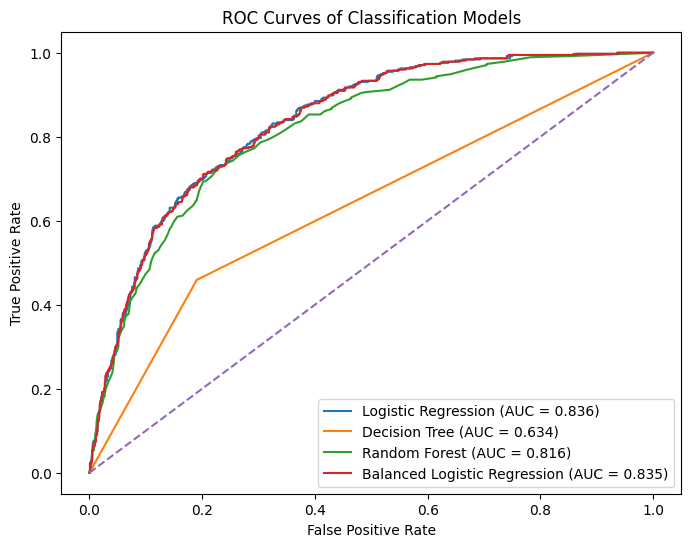

In [53]:
from sklearn.metrics import roc_curve

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_bal, tpr_bal, _ = roc_curve(y_test, y_prob_balanced)

plt.figure(figsize=(8, 6))

plt.plot(fpr_lr, tpr_lr,
         label=f"Logistic Regression (AUC = {roc_auc_lr:.3f})")

plt.plot(fpr_dt, tpr_dt,
         label=f"Decision Tree (AUC = {roc_auc_dt:.3f})")

plt.plot(fpr_rf, tpr_rf,
         label=f"Random Forest (AUC = {roc_auc_rf:.3f})")

plt.plot(fpr_bal, tpr_bal,
         label=f"Balanced Logistic Regression (AUC = {roc_auc_balanced:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curves of Classification Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

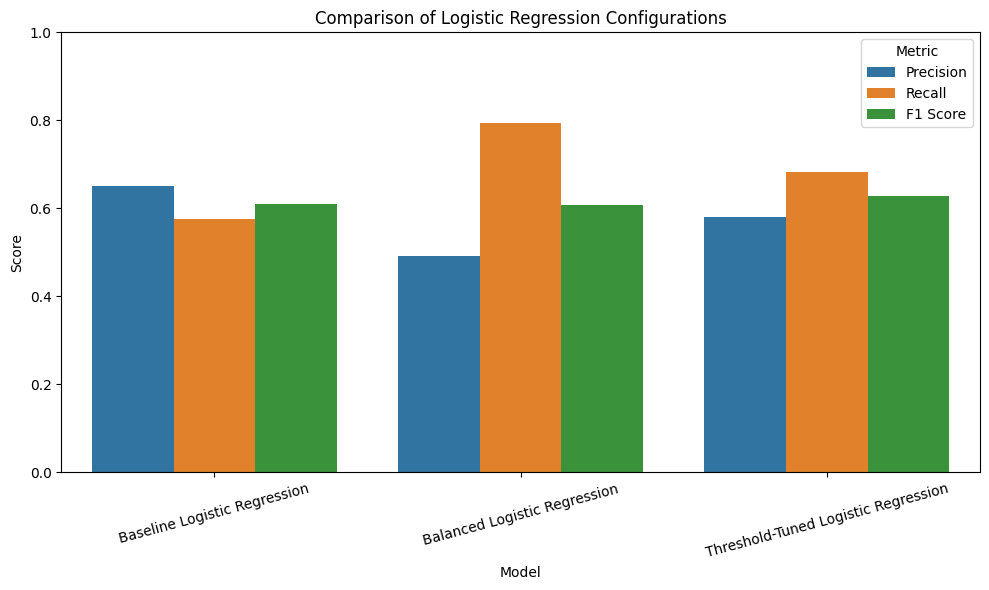

In [54]:
comparison_plot = final_logistic_comparison.melt(
    id_vars="Model",
    value_vars=[
        "Precision",
        "Recall",
        "F1 Score"
    ],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=comparison_plot,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Comparison of Logistic Regression Configurations")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=15)

plt.legend(title="Metric")
plt.tight_layout()

plt.show()

In [55]:
feature_names = logistic_model.named_steps[
    "preprocessor"
].get_feature_names_out()

coefficients = logistic_model.named_steps[
    "classifier"
].coef_[0]

coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coefficient_df = coefficient_df.sort_values(
    by="Coefficient",
    ascending=False
)

print("Features Associated with Higher Churn Probability:")
display(coefficient_df.head(10))

print("Features Associated with Lower Churn Probability:")
display(coefficient_df.tail(10).sort_values("Coefficient"))

Features Associated with Higher Churn Probability:


,Feature,Coefficient
10,cat__InternetService_Fiber optic,1.107407
3,num__TotalCharges,0.645508
28,cat__PaymentMethod_Electronic check,0.379150
21,cat__StreamingTV_Yes,0.372407
9,cat__MultipleLines_Yes,0.362784
23,cat__StreamingMovies_Yes,0.344649
26,cat__PaperlessBilling_Yes,0.290931
17,cat__DeviceProtection_Yes,0.074264
29,cat__PaymentMethod_Mailed check,0.072700
0,num__SeniorCitizen,0.072159


Features Associated with Lower Churn Probability:


,Feature,Coefficient
25,cat__Contract_Two year,-1.364823
1,num__tenure,-1.357404
24,cat__Contract_One year,-0.750068
7,cat__PhoneService_Yes,-0.515337
2,num__MonthlyCharges,-0.434497
13,cat__OnlineSecurity_Yes,-0.373187
19,cat__TechSupport_Yes,-0.331578
6,cat__Dependents_Yes,-0.232176
8,cat__MultipleLines_No phone service,-0.168627
12,cat__OnlineSecurity_No internet service,-0.166359


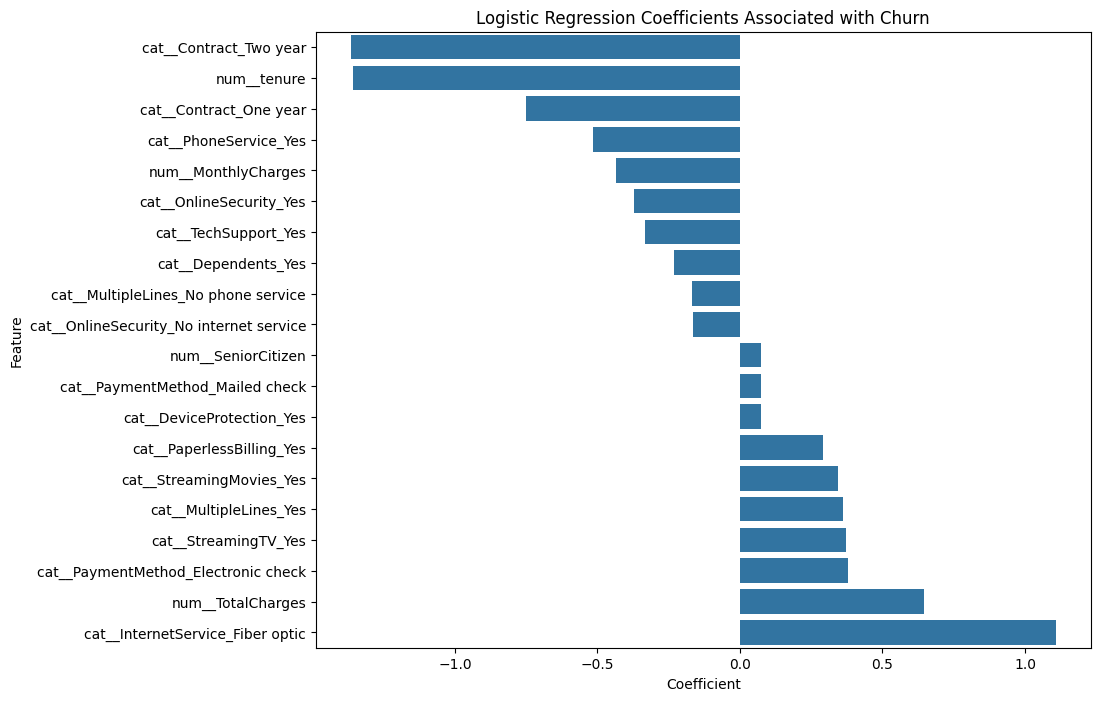

In [56]:
top_positive = coefficient_df.head(10)

top_negative = coefficient_df.tail(10)

important_coefficients = pd.concat([
    top_negative,
    top_positive
]).sort_values("Coefficient")

plt.figure(figsize=(10, 8))

sns.barplot(
    data=important_coefficients,
    x="Coefficient",
    y="Feature"
)

plt.title("Logistic Regression Coefficients Associated with Churn")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.show()

### Coefficient Interpretation

The coefficients of the Logistic Regression model were examined to understand which customer characteristics were associated with higher or lower predicted churn probability.

Positive coefficients indicate an association with higher predicted log-odds of churn, while negative coefficients indicate an association with lower predicted log-odds of churn, assuming other model features remain constant.

Because numerical variables were standardized before model training, their coefficients represent the effect of a one-standard-deviation increase in the corresponding numerical feature.

Categorical feature coefficients represent differences relative to the reference category removed during one-hot encoding.

The coefficient analysis provides model-level associations and should not be interpreted as evidence that individual customer characteristics directly cause churn.

## Final Model Selection

The Threshold-Tuned Logistic Regression model was selected as the final model for this project.

The baseline Logistic Regression model achieved the highest accuracy and strong ROC-AUC performance but identified only approximately 57.5% of customers who churned.

Balanced class weighting increased churn recall to approximately 79.4%, but this improvement resulted in substantially lower precision and a large increase in false-positive predictions.

Threshold tuning provided a better balance between these objectives. The Threshold-Tuned Logistic Regression model achieved a recall of approximately 68.2% and the highest F1-score of approximately 62.7% among the evaluated Logistic Regression configurations.

The underlying Logistic Regression model also demonstrated stable generalization performance, achieving a mean five-fold cross-validation ROC-AUC score of approximately 0.845.

Therefore, the Threshold-Tuned Logistic Regression model was selected because it provided the best balance between precision and recall while maintaining strong overall ranking performance.

The selected threshold was optimized using the test dataset for demonstration purposes. In a production workflow, threshold optimization should be performed using validation data or cross-validation before final evaluation on an untouched test dataset.

## Conclusion

This project developed a machine learning classification workflow for predicting customer churn using demographic information, service subscriptions, contract characteristics, payment methods, tenure, and customer charges.

Exploratory Data Analysis revealed meaningful churn patterns. Customers using electronic check payments and fiber optic internet service exhibited substantially higher churn rates. The dataset also contained moderate class imbalance, with approximately 26.5% of customers belonging to the churn class.

The dataset was cleaned by converting TotalCharges to numerical format, removing a small number of observations with missing TotalCharges values, and removing the customerID identifier column.

Numerical features were standardized and categorical variables were transformed using one-hot encoding within a machine learning pipeline.

Logistic Regression, Decision Tree, and Random Forest classifiers were evaluated. Logistic Regression achieved the strongest overall generalization performance, with a test ROC-AUC score of approximately 0.836 and a mean five-fold cross-validation ROC-AUC score of approximately 0.845.

Decision Tree and Random Forest exhibited overfitting, while Logistic Regression demonstrated stable training, testing, and cross-validation performance.

Balanced class weighting substantially improved churn recall but produced more false-positive predictions. Threshold tuning provided a better balance between precision and recall and achieved the highest F1-score among the evaluated Logistic Regression configurations.

Overall, the project demonstrates the importance of selecting evaluation metrics and classification thresholds according to the business objective rather than relying only on classification accuracy.

Future improvements could include validation-based threshold optimization, hyperparameter tuning, gradient boosting models, probability calibration, SHAP-based model interpretation, and cost-sensitive evaluation based on the financial impact of false-positive and false-negative predictions.